# 👩‍💻 Optimize Your Training Pipeline with Efficiency Tricks

## 📋 Overview
In this activity, you'll enhance the training efficiency and stability of a Convolutional Neural Network on the CIFAR-10 dataset by integrating advanced techniques such as gradient clipping, learning rate scheduling, and mixed precision training. These optimizations are crucial in real-world machine learning scenarios where computational resources and time are often limited, but model performance cannot be sacrificed.

This activity ties into practical scenarios where you might need to improve model training efficiency and reliability, essential skills for machine learning engineers and data scientists.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Integrate gradient clipping into training pipelines to manage updates and prevent instability.
- Apply learning rate scheduling to enhance model convergence rates and accuracy.
- Use mixed precision training to reduce training time and improve resource utilization efficiently.

## Task 1: Baseline Model Training
**Context:** Start by setting up a baseline training for your CNN model on CIFAR-10.

In [1]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Data preparation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10 training and validation datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
val_dataset = datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

# Create data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=64, shuffle=False)

# Simple CNN architecture
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)
    
    # TODO: Implement the forward pass
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

        pass

# Training function
# TODO: Implement the baseline training loop
# 1. Record start time
# 2. Initialize lists to store metrics
# 3. Loop through epochs
# 4. Loop through batches
# 5. Forward pass
# 6. Calculate loss
# 7. Backward pass
# 8. Update weights
# 9. Record metrics
# 10. Calculate epoch statistics

def train_baseline(model, train_loader, criterion, optimizer, num_epochs=5):
    device = next(model.parameters()).device
    start_time = time.time()
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward and optimize
            loss.backward()
            optimizer.step()
            
            # Track statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        # Calculate epoch statistics
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Train Loss: {epoch_loss:.4f}, '
              f'Train Acc: {epoch_acc:.2f}%, '
              f'Val Loss: {val_loss:.4f}, '
              f'Val Acc: {val_acc:.2f}%')
    
    training_time = time.time() - start_time
    print(f'Training time: {training_time:.2f} seconds')
    
    return train_losses, val_losses, train_accuracies, val_accuracies, training_time

# Validation function
# TODO: Implement the validation function
# 1. Set model to evaluation mode
# 2. Disable gradient computation
# 3. Calculate validation loss and accuracy

def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return val_loss / len(val_loader), 100 * correct / total


# Initialize model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Train the baseline model
num_epochs = 5 # or more when trying out iterations
train_losses, val_losses, train_accuracies, val_accuracies, training_time = train_baseline(
    model, train_loader, criterion, optimizer, num_epochs)

# Plot results
# TODO: Plot training and validation losses and accuracies

Epoch 1/5, Train Loss: 1.5224, Train Acc: 44.72%, Val Loss: 1.1801, Val Acc: 56.65%
Epoch 2/5, Train Loss: 1.0531, Train Acc: 62.39%, Val Loss: 0.9987, Val Acc: 64.73%
Epoch 3/5, Train Loss: 0.8473, Train Acc: 70.12%, Val Loss: 0.8880, Val Acc: 68.90%
Epoch 4/5, Train Loss: 0.6850, Train Acc: 76.14%, Val Loss: 0.8049, Val Acc: 72.45%
Epoch 5/5, Train Loss: 0.5394, Train Acc: 81.05%, Val Loss: 0.8128, Val Acc: 73.08%
Training time: 55.93 seconds


## 🔍 Practice
1. Complete the `forward` method in the `SimpleCNN` class.
2. Implement the `train_baseline` function to train the model for `num_epochs`:
    - Use `model.train()` to set the training mode
    - Utilize `torch.no_grad()` for validation
    - Track time with `time.time()`
    - Calculate accuracy with `torch.max(outputs, 1)[1].eq(labels).sum().item()`
3. Implement the validate function to evaluate model performance.
4. Add code to plot the training/validation loss and accuracy curves.
    
## ✅ Success Checklist
- Baseline model is trained without any optimizations.
- Loss curve and training time are recorded.
- Model achieves reasonable accuracy on the validation set.

## 💡 Key Points
- Monitoring baseline performance allows clear comparisons when implementing optimizations.
- Understanding default training dynamics is foundational for troubleshooting enhancements.
- Pay attention to the learning rate, batch size, and number of epochs as they affect convergence.

## Task 2: Applying Gradient Clipping
**Context:** Enhance training stability by incorporating gradient clipping into your model training.

In [2]:
# TODO: Implement training with gradient clipping
# 1. Record start time
# 2. Initialize lists to store metrics
# 3. Loop through epochs
# 4. Loop through batches
# 5. Forward pass
# 6. Calculate loss
# 7. Backward pass
# 8. Apply gradient clipping with torch.nn.utils.clip_grad_norm_
# 9. Update weights
# 10. Record metrics
# 11. Calculate epoch statistics

# Training function with gradient clipping
def train_with_gradient_clipping(model, train_loader, criterion, optimizer, num_epochs=5, max_norm=1.0):
    device = next(model.parameters()).device
    start_time = time.time()
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass
            loss.backward()
            
            # Apply gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
            
            # Optimize
            optimizer.step()
            
            # Track statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        # Calculate epoch statistics
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Train Loss: {epoch_loss:.4f}, '
              f'Train Acc: {epoch_acc:.2f}%, '
              f'Val Loss: {val_loss:.4f}, '
              f'Val Acc: {val_acc:.2f}%')
    
    training_time = time.time() - start_time
    print(f'Training time with gradient clipping: {training_time:.2f} seconds')
    
    return train_losses, val_losses, train_accuracies, val_accuracies, training_time


# Initialize new model and optimizer for gradient clipping experiment
model_gc = SimpleCNN().to(device)
optimizer_gc = optim.SGD(model_gc.parameters(), lr=0.01, momentum=0.9)

# Train with gradient clipping
max_norm = 1.0  # Try different values like 0.5, 1.0, 2.0
train_losses_gc, val_losses_gc, train_accuracies_gc, val_accuracies_gc, training_time_gc = train_with_gradient_clipping(
    model_gc, train_loader, criterion, optimizer_gc, num_epochs, max_norm)

# Plot and compare results
# TODO: Plot and compare results with baseline

Epoch 1/5, Train Loss: 1.6281, Train Acc: 41.27%, Val Loss: 1.3654, Val Acc: 51.17%
Epoch 2/5, Train Loss: 1.2658, Train Acc: 54.44%, Val Loss: 1.1785, Val Acc: 57.88%
Epoch 3/5, Train Loss: 1.1021, Train Acc: 60.83%, Val Loss: 1.0684, Val Acc: 62.20%
Epoch 4/5, Train Loss: 0.9779, Train Acc: 65.47%, Val Loss: 1.0012, Val Acc: 64.84%
Epoch 5/5, Train Loss: 0.8807, Train Acc: 69.12%, Val Loss: 0.9341, Val Acc: 67.24%
Training time with gradient clipping: 57.26 seconds


## 🔍 Practice
1. Implement the `train_with_gradient_clipping` function:
    - Copy your baseline training loop
    - Add `torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)` after `loss.backward()`
    - Experiment with different `max_norm `values (0.5, 1.0, 2.0)
2. Compare the training stability and convergence with the baseline.
3. Visualize the gradient norms during training using a histogram or line plot.

## ✅ Success Checklist
- Model training includes gradient clipping.
- Training is more stable with fewer spikes in the loss curve.
- The effect of different `max_norm` values is documented.

## ❗ Common Mistakes
- Setting `max_norm` too small can slow down learning.
- Setting `max_norm` too large might not provide enough constraint on exploding gradients.
- Applying gradient clipping after optimizer step instead of before.

## Task 3: Implementing Learning Rate Scheduling
**Context:** Use dynamic learning rates to potentially enhance convergence.

In [3]:
# TODO: Implement training with learning rate scheduling
# 1. Record start time
# 2. Initialize lists to store metrics
# 3. Loop through epochs
# 4. Loop through batches
# 5. Forward pass
# 6. Calculate loss
# 7. Backward pass
# 8. Update weights
# 9. Record metrics
# 10. Step the scheduler (based on scheduler type)
# 11. Calculate epoch statistics

def train_with_lr_scheduler(model, train_loader, criterion, optimizer, scheduler, num_epochs=5):
    device = next(model.parameters()).device
    start_time = time.time()
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    lr_history = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        # Record current learning rate
        lr_history.append(optimizer.param_groups[0]['lr'])
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward and optimize
            loss.backward()
            optimizer.step()
            
            # Track statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        # Calculate epoch statistics
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        # Step the scheduler
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()
        
        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'LR: {optimizer.param_groups[0]["lr"]:.6f}, '
              f'Train Loss: {epoch_loss:.4f}, '
              f'Train Acc: {epoch_acc:.2f}%, '
              f'Val Loss: {val_loss:.4f}, '
              f'Val Acc: {val_acc:.2f}%')
    
    training_time = time.time() - start_time
    print(f'Training time with LR scheduling: {training_time:.2f} seconds')
    
    return train_losses, val_losses, train_accuracies, val_accuracies, training_time, lr_history

# Initialize model and optimizer for learning rate scheduling
model_lr = SimpleCNN().to(device)
optimizer_lr = optim.SGD(model_lr.parameters(), lr=0.01, momentum=0.9)

# Create a learning rate scheduler
# Try different schedulers:
# scheduler = optim.lr_scheduler.StepLR(optimizer_lr, step_size=2, gamma=0.5)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_lr, mode='min', factor=0.5, patience=1)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer_lr, T_max=num_epochs)
scheduler = optim.lr_scheduler.StepLR(optimizer_lr, step_size=2, gamma=0.5)

# Train with learning rate scheduling
train_losses_lr, val_losses_lr, train_accuracies_lr, val_accuracies_lr, training_time_lr, lr_history = train_with_lr_scheduler(
    model_lr, train_loader, criterion, optimizer_lr, scheduler, num_epochs)

# Plot and compare results
# TODO: Plot learning rate changes and compare results with baseline

Epoch 1/5, LR: 0.010000, Train Loss: 1.5298, Train Acc: 44.63%, Val Loss: 1.2131, Val Acc: 57.70%
Epoch 2/5, LR: 0.005000, Train Loss: 1.0671, Train Acc: 62.12%, Val Loss: 1.0132, Val Acc: 64.42%
Epoch 3/5, LR: 0.005000, Train Loss: 0.8109, Train Acc: 71.65%, Val Loss: 0.8707, Val Acc: 69.75%
Epoch 4/5, LR: 0.002500, Train Loss: 0.7026, Train Acc: 75.45%, Val Loss: 0.8327, Val Acc: 71.21%
Epoch 5/5, LR: 0.002500, Train Loss: 0.5488, Train Acc: 81.22%, Val Loss: 0.8155, Val Acc: 72.46%
Training time with LR scheduling: 55.22 seconds


## 🔍 Practice
1. Implement the `train_with_lr_scheduler` function:
    - Copy your baseline training loop
    - Add scheduler stepping logic (`scheduler.step()`) at the appropriate point:
        - For epoch-based schedulers like `StepLR` or `CosineAnnealingLR`: call `scheduler.step()` at the end of each epoch
        - For metric-based schedulers like `ReduceLROnPlateau`: call `scheduler.step(val_loss)` after validation
    - Track the learning rate history using `optimizer.param_groups[0]['lr']`
2. Experiment with different scheduler types:
    - `StepLR`: Decreases the learning rate by a factor gamma every step_size epochs
    - `ReduceLROnPlateau`: Reduces learning rate when a metric stops improving
    - `CosineAnnealingLR`: Uses a cosine annealing schedule
3. Plot the learning rate over time and compare convergence with the baseline.

## ✅ Success Checklist
- Learning rate scheduler is correctly implemented.
- Learning rate changes are visualized throughout training.
- Convergence improvements are observed compared to baseline.

## 💡 Key Points
- Different schedulers work best for different problems.
- Learning rate scheduling can help escape local minima and reach better solutions.
- Monitoring the learning rate alongside loss helps understand training dynamics.

## Task 4: Experimenting with Mixed Precision 
**Context:** Speed up your training using mixed precision with PyTorch's `torch.cuda.amp`.

In [4]:
from torch.cuda.amp import autocast, GradScaler

# TODO: Implement training with mixed precision
# 1. Create a GradScaler
# 2. Record start time
# 3. Initialize lists to store metrics
# 4. Loop through epochs
# 5. Loop through batches
# 6. Forward pass with autocast
# 7. Calculate loss
# 8. Scale loss and backpropagate
# 9. Unscale before gradient clipping (optional)
# 10. Scale optimizer's step
# 11. Update weights
# 12. Record metrics
# 13. Calculate epoch statistics

# Training function with mixed precision
def train_with_mixed_precision(model, train_loader, criterion, optimizer, num_epochs=5):
    device = next(model.parameters()).device
    start_time = time.time()
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    # Create GradScaler for mixed precision training
    scaler = GradScaler()
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass with mixed precision
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            # Backward and optimize with scaled gradients
            scaler.scale(loss).backward()
            
            # Optionally unscale gradients for clipping
            # scaler.unscale_(optimizer)
            # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
            
            # Step with scaler
            scaler.step(optimizer)
            scaler.update()
            
            # Track statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        # Calculate epoch statistics
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        # Validate (no need for mixed precision in evaluation)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Train Loss: {epoch_loss:.4f}, '
              f'Train Acc: {epoch_acc:.2f}%, '
              f'Val Loss: {val_loss:.4f}, '
              f'Val Acc: {val_acc:.2f}%')
    
    training_time = time.time() - start_time
    max_memory = torch.cuda.max_memory_allocated() / (1024**2) if torch.cuda.is_available() else 0
    print(f'Training time with mixed precision: {training_time:.2f} seconds')
    print(f'Maximum GPU memory used: {max_memory:.2f} MB')
    
    return train_losses, val_losses, train_accuracies, val_accuracies, training_time

# Check if GPU supports mixed precision
if not torch.cuda.is_available():
    print("CUDA not available. Mixed precision requires CUDA.")
else:
    # Initialize model and optimizer for mixed precision
    model_mp = SimpleCNN().to(device)
    optimizer_mp = optim.SGD(model_mp.parameters(), lr=0.01, momentum=0.9)
    
    # Train with mixed precision
    train_losses_mp, val_losses_mp, train_accuracies_mp, val_accuracies_mp, training_time_mp = train_with_mixed_precision(
        model_mp, train_loader, criterion, optimizer_mp, num_epochs)
    
    # Plot and compare results
    # TODO: Plot and compare results with baseline, especially training time

Epoch 1/5, Train Loss: 1.5325, Train Acc: 44.72%, Val Loss: 1.1782, Val Acc: 58.86%
Epoch 2/5, Train Loss: 1.0688, Train Acc: 62.15%, Val Loss: 0.9761, Val Acc: 66.04%
Epoch 3/5, Train Loss: 0.8593, Train Acc: 69.78%, Val Loss: 0.9579, Val Acc: 66.14%
Epoch 4/5, Train Loss: 0.7007, Train Acc: 75.60%, Val Loss: 0.8649, Val Acc: 69.74%
Epoch 5/5, Train Loss: 0.5533, Train Acc: 80.63%, Val Loss: 0.8005, Val Acc: 73.26%
Training time with mixed precision: 57.79 seconds
Maximum GPU memory used: 132.00 MB


## 🔍 Practice
1. Implement the `train_with_mixed_precision` function:
    - Create a `GradScaler` instance: `scaler = GradScaler()`
    - Wrap the forward pass in `with autocast():`
    - Scale the loss: `scaler.scale(loss).backward()`
    - If using gradient clipping, unscale first: `scaler.unscale_(optimizer)`
    - Update weights with scaled gradients: `scaler.step(optimizer)`
    - Update scaler state: `scaler.update()`
2. Track memory usage with `torch.cuda.max_memory_allocated() / (1024**2)` (in MB).
3. Compare training time and resource usage with the baseline.

## ✅ Success Checklist
- Mixed precision implementation is successful.
- Training time is reduced compared to baseline.
- Memory usage is reduced without degrading accuracy.

## ❗ Common Mistakes
- Not using `scaler.update()` after each optimizer step.
- Using mixed precision on hardware that doesn't support it (older GPUs).
- Not handling `inf/NaN` values that might occur more frequently with mixed precision.

## Task 5: Analysis and Visualization
**Context:** Visualize and compare outcomes of all optimizations for comprehensive analysis.

In [5]:
# TODO: Implement comparison plotting
# 1. Create figure and axis
# 2. Plot each configuration's metric
# 3. Add legend, labels, and title
# 4. Display or save the plot

# Plotting function for comparison
def plot_comparison(metrics_dict, metric_name, title, xlabel='Epoch', ylabel=None, figsize=(10, 6)):
    
    """
    Plot comparison of different training configurations.
    
    Args:
        metrics_dict: Dictionary with configuration names as keys and metric lists as values
        metric_name: Name of the metric being plotted (for axis label)
        title: Plot title
    """
        
    if ylabel is None:
        ylabel = metric_name
    
    plt.figure(figsize=figsize)
    for name, metric in metrics_dict.items():
        plt.plot(range(1, len(metric) + 1), metric, marker='o', label=name)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Prepare data for comparisons
training_times = {
    'Baseline': training_time,
    'Gradient Clipping': training_time_gc,
    'LR Scheduling': training_time_lr,
    'Mixed Precision': training_time_mp
}

# Organize metrics for plotting
train_losses_dict = {
    'Baseline': train_losses,
    'Gradient Clipping': train_losses_gc,
    'LR Scheduling': train_losses_lr,
    'Mixed Precision': train_losses_mp
}

val_accuracies_dict = {
    'Baseline': val_accuracies,
    'Gradient Clipping': val_accuracies_gc,
    'LR Scheduling': val_accuracies_lr,
    'Mixed Precision': val_accuracies_mp
}

# Plot comparisons
# TODO: Create comparison plots for training time, loss curves, and accuracy

Using device: cuda

=== Training Baseline Model ===
Epoch 1/5, Train Loss: 1.5335, Train Acc: 44.69%, Val Loss: 1.1788, Val Acc: 58.52%
Epoch 2/5, Train Loss: 1.0778, Train Acc: 61.81%, Val Loss: 1.0374, Val Acc: 62.95%
Epoch 3/5, Train Loss: 0.8598, Train Acc: 69.85%, Val Loss: 0.8529, Val Acc: 70.03%
Epoch 4/5, Train Loss: 0.6998, Train Acc: 75.36%, Val Loss: 0.8385, Val Acc: 70.73%
Epoch 5/5, Train Loss: 0.5489, Train Acc: 80.92%, Val Loss: 0.7852, Val Acc: 73.71%
Training time: 55.54 seconds

=== Training Model with Gradient Clipping ===
Epoch 1/5, Train Loss: 1.6263, Train Acc: 41.39%, Val Loss: 1.3668, Val Acc: 51.35%
Epoch 2/5, Train Loss: 1.2672, Train Acc: 54.72%, Val Loss: 1.1870, Val Acc: 57.89%
Epoch 3/5, Train Loss: 1.0975, Train Acc: 61.24%, Val Loss: 1.0564, Val Acc: 62.40%
Epoch 4/5, Train Loss: 0.9756, Train Acc: 65.79%, Val Loss: 0.9697, Val Acc: 66.23%
Epoch 5/5, Train Loss: 0.8753, Train Acc: 69.24%, Val Loss: 0.9275, Val Acc: 67.74%
Training time with gradient clip

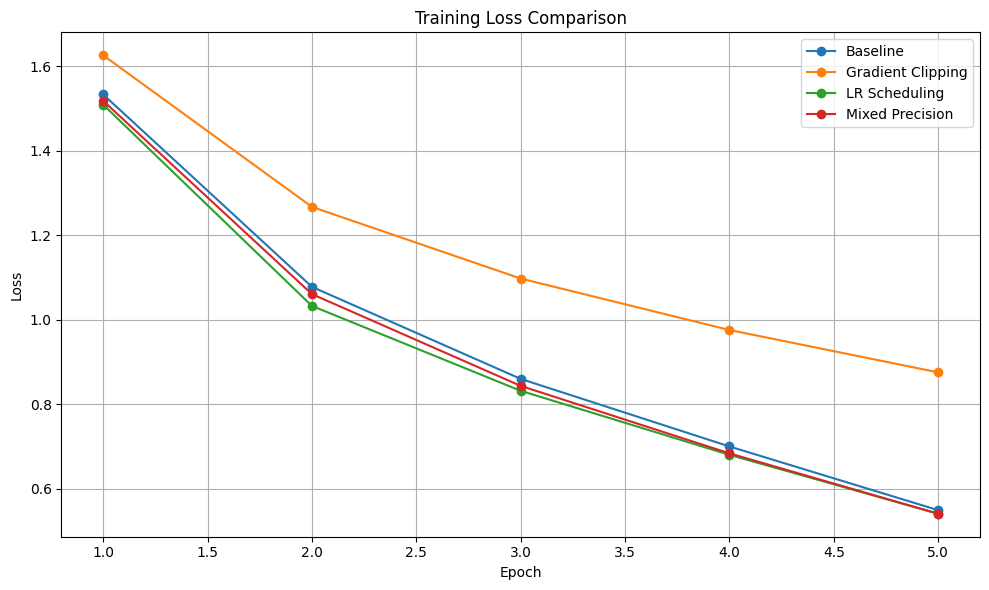

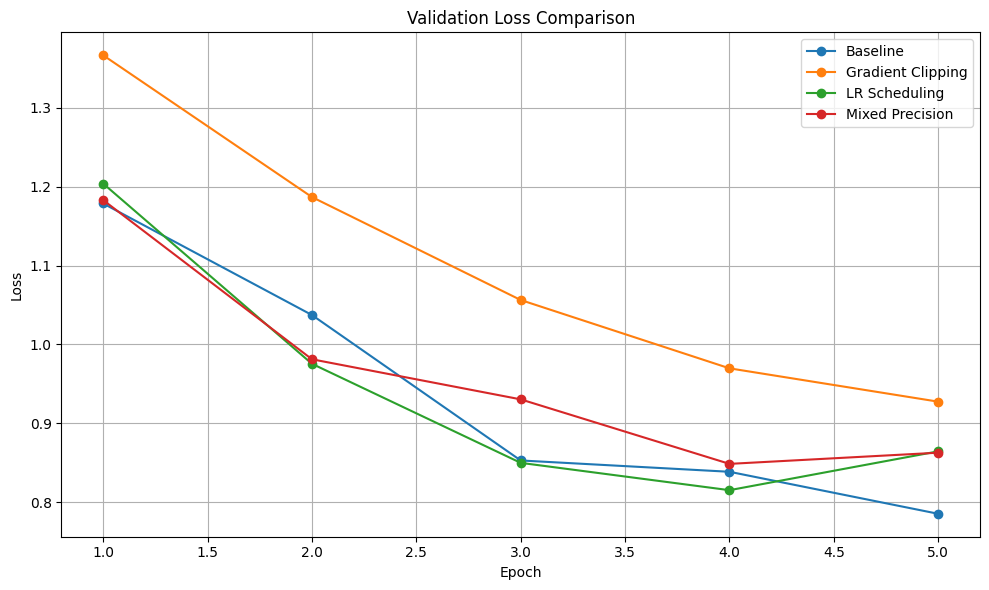

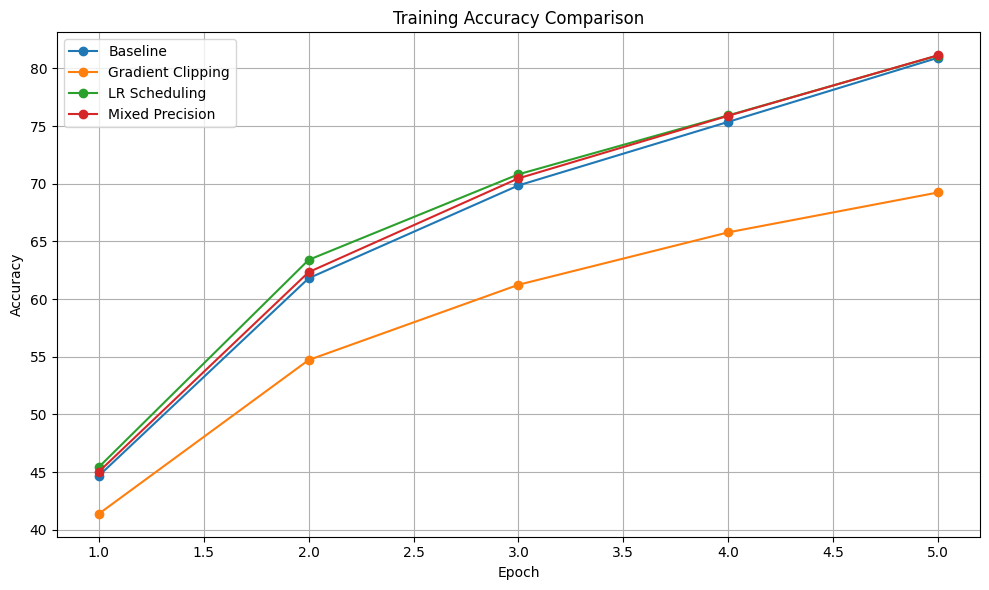

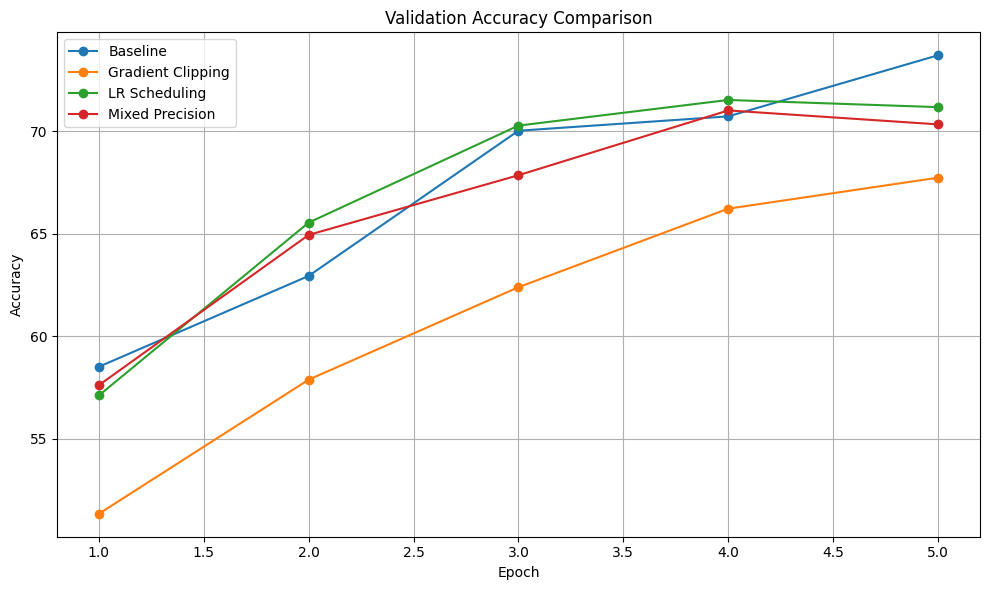

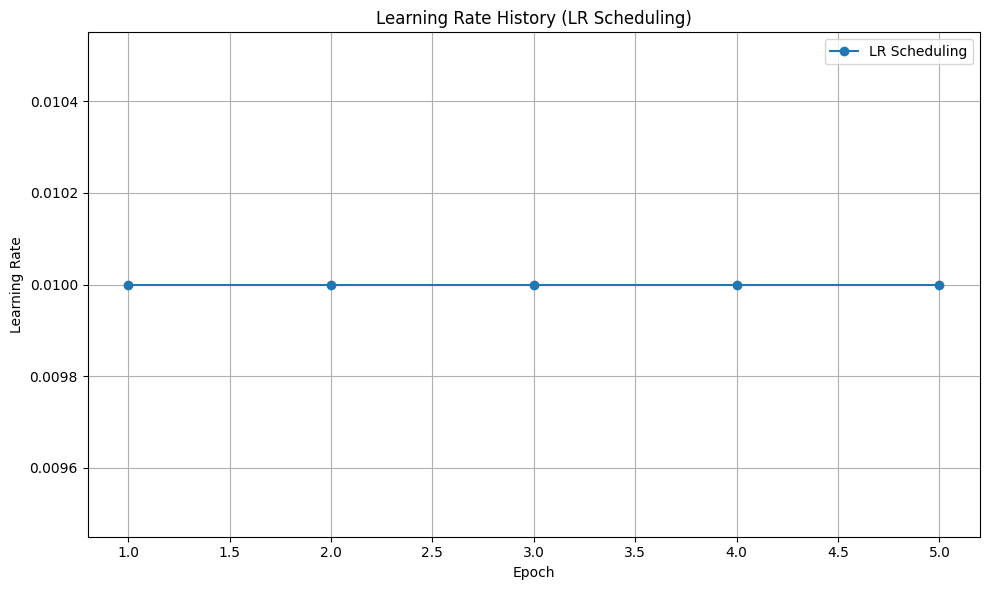


=== Summary of Training Times ===
Baseline Training Time: 55.54 seconds
Gradient Clipping Training Time: 56.40 seconds
LR Scheduling Training Time: 55.48 seconds
Mixed Precision Training Time: 57.57 seconds
Mixed Precision Max GPU Memory (Last Run): 180.58 MB


In [7]:
# Main execution
if __name__ == "__main__":
    # Device configuration
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Set parameters
#     num_epochs = 10 # Increased epochs for better observation
    num_epochs = 5
    
    # --- 1. Baseline model ---
    print("\n=== Training Baseline Model ===")
    model_baseline = SimpleCNN().to(device)
    criterion_baseline = nn.CrossEntropyLoss()
    optimizer_baseline = optim.SGD(model_baseline.parameters(), lr=0.01, momentum=0.9)
    
    (baseline_train_losses, baseline_val_losses,
     baseline_train_accuracies, baseline_val_accuracies,
     baseline_time) = train_baseline(
        model_baseline, train_loader, criterion_baseline, optimizer_baseline, num_epochs)
    
    # --- 2. Model with gradient clipping ---
    print("\n=== Training Model with Gradient Clipping ===")
    model_gc = SimpleCNN().to(device)
    criterion_gc = nn.CrossEntropyLoss()
    optimizer_gc = optim.SGD(model_gc.parameters(), lr=0.01, momentum=0.9)
    
    (gc_train_losses, gc_val_losses,
     gc_train_accuracies, gc_val_accuracies,
     gc_time) = train_with_gradient_clipping(
        model_gc, train_loader, criterion_gc, optimizer_gc, num_epochs, max_norm=1.0)
    
    # --- 3. Model with learning rate scheduling ---
    print("\n=== Training Model with Learning Rate Scheduling ===")
    model_lr = SimpleCNN().to(device)
    criterion_lr = nn.CrossEntropyLoss()
    optimizer_lr = optim.SGD(model_lr.parameters(), lr=0.01, momentum=0.9)
    # Example: ReduceLROnPlateau scheduler
#     scheduler_lr = optim.lr_scheduler.ReduceLROnPlateau(optimizer_lr, mode='min', factor=0.1, patience=3, verbose=True)
    scheduler_lr = optim.lr_scheduler.ReduceLROnPlateau(optimizer_lr, mode='min', factor=0.1, patience=3)
    
    (lr_train_losses, lr_val_losses,
     lr_train_accuracies, lr_val_accuracies,
     lr_time, lr_history) = train_with_lr_scheduler(
        model_lr, train_loader, criterion_lr, optimizer_lr, scheduler_lr, num_epochs)

    # --- 4. Model with Mixed Precision Training ---
    print("\n=== Training Model with Mixed Precision ===")
    # Reset CUDA memory stats for a cleaner measurement
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

    model_mp = SimpleCNN().to(device)
    criterion_mp = nn.CrossEntropyLoss()
    optimizer_mp = optim.SGD(model_mp.parameters(), lr=0.01, momentum=0.9)

    (mp_train_losses, mp_val_losses,
     mp_train_accuracies, mp_val_accuracies,
     mp_time) = train_with_mixed_precision(
        model_mp, train_loader, criterion_mp, optimizer_mp, num_epochs)

    # --- Plotting Results ---
    print("\n=== Plotting Results ===")

    # Plot Training Loss
    plot_comparison(
        {'Baseline': baseline_train_losses,
         'Gradient Clipping': gc_train_losses,
         'LR Scheduling': lr_train_losses,
         'Mixed Precision': mp_train_losses},
        'Loss', 'Training Loss Comparison'
    )

    # Plot Validation Loss
    plot_comparison(
        {'Baseline': baseline_val_losses,
         'Gradient Clipping': gc_val_losses,
         'LR Scheduling': lr_val_losses,
         'Mixed Precision': mp_val_losses},
        'Loss', 'Validation Loss Comparison'
    )

    # Plot Training Accuracy
    plot_comparison(
        {'Baseline': baseline_train_accuracies,
         'Gradient Clipping': gc_train_accuracies,
         'LR Scheduling': lr_train_accuracies,
         'Mixed Precision': mp_train_accuracies},
        'Accuracy', 'Training Accuracy Comparison'
    )

    # Plot Validation Accuracy
    plot_comparison(
        {'Baseline': baseline_val_accuracies,
         'Gradient Clipping': gc_val_accuracies,
         'LR Scheduling': lr_val_accuracies,
         'Mixed Precision': mp_val_accuracies},
        'Accuracy', 'Validation Accuracy Comparison'
    )

    # Plot Learning Rate History for LR Scheduling
    plot_comparison(
        {'LR Scheduling': lr_history},
        'Learning Rate', 'Learning Rate History (LR Scheduling)', ylabel='Learning Rate'
    )

    # Print summary of training times
    print("\n=== Summary of Training Times ===")
    print(f"Baseline Training Time: {baseline_time:.2f} seconds")
    print(f"Gradient Clipping Training Time: {gc_time:.2f} seconds")
    print(f"LR Scheduling Training Time: {lr_time:.2f} seconds")
    print(f"Mixed Precision Training Time: {mp_time:.2f} seconds")

    if torch.cuda.is_available():
        print(f"Mixed Precision Max GPU Memory (Last Run): {torch.cuda.max_memory_allocated() / (1024**2):.2f} MB")

## 🔍 Practice
1. Implement the `plot_comparison` function using `matplotlib`:
    - Use different colors and markers for each configuration
    - Include a legend to identify each configuration
    - Add clear axis labels and an informative title
2. Create comparison plots for:
    - Training time (bar chart)
    - Training loss curves (line chart)
    - Validation accuracy (line chart)
3. Analyze which optimization(s) provided the most benefits and why.

## ✅ Success Checklist
- Visual comparisons clearly show differences between configurations.
- Analysis identifies the most effective optimizations for this scenario.
-  Time and resource trade-offs are discussed.

## 💡 Key Points
- Different optimizations may affect different aspects of training.
- The best approach often combines multiple techniques.
- Consider the computational cost vs. performance improvement trade-off.

## ❗ Common Mistakes to Avoid
- Comparing implementations with different random seeds, causing unfair comparisons.
- Overlooking differences in training dynamics between CPU/GPU setups.
- Misconfiguring gradient clipping or schedulers leading to suboptimal results.
- Not accounting for overhead when measuring training time.

## 💻 Referance Solution

<details>

<summary><strong>Click HERE to see a reference solution</strong></summary>    
    
```python
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt
import numpy as np
from torch.cuda.amp import autocast, GradScaler

# Set random seed for reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Data preparation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10 training and validation datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
val_dataset = datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

# Create data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=64, shuffle=False)

# Simple CNN architecture
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Validation function used by all training methods
def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return val_loss / len(val_loader), 100 * correct / total

# Training function for baseline
def train_baseline(model, train_loader, criterion, optimizer, num_epochs=5):
    device = next(model.parameters()).device
    start_time = time.time()
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward and optimize
            loss.backward()
            optimizer.step()
            
            # Track statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        # Calculate epoch statistics
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Train Loss: {epoch_loss:.4f}, '
              f'Train Acc: {epoch_acc:.2f}%, '
              f'Val Loss: {val_loss:.4f}, '
              f'Val Acc: {val_acc:.2f}%')
    
    training_time = time.time() - start_time
    print(f'Training time: {training_time:.2f} seconds')
    
    return train_losses, val_losses, train_accuracies, val_accuracies, training_time

# Training function with gradient clipping
def train_with_gradient_clipping(model, train_loader, criterion, optimizer, num_epochs=5, max_norm=1.0):
    device = next(model.parameters()).device
    start_time = time.time()
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass
            loss.backward()
            
            # Apply gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
            
            # Optimize
            optimizer.step()
            
            # Track statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        # Calculate epoch statistics
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Train Loss: {epoch_loss:.4f}, '
              f'Train Acc: {epoch_acc:.2f}%, '
              f'Val Loss: {val_loss:.4f}, '
              f'Val Acc: {val_acc:.2f}%')
    
    training_time = time.time() - start_time
    print(f'Training time with gradient clipping: {training_time:.2f} seconds')
    
    return train_losses, val_losses, train_accuracies, val_accuracies, training_time

# Training function with learning rate scheduling
def train_with_lr_scheduler(model, train_loader, criterion, optimizer, scheduler, num_epochs=5):
    device = next(model.parameters()).device
    start_time = time.time()
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    lr_history = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        # Record current learning rate
        lr_history.append(optimizer.param_groups[0]['lr'])
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward and optimize
            loss.backward()
            optimizer.step()
            
            # Track statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        # Calculate epoch statistics
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        # Step the scheduler
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()
        
        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'LR: {optimizer.param_groups[0]["lr"]:.6f}, '
              f'Train Loss: {epoch_loss:.4f}, '
              f'Train Acc: {epoch_acc:.2f}%, '
              f'Val Loss: {val_loss:.4f}, '
              f'Val Acc: {val_acc:.2f}%')
    
    training_time = time.time() - start_time
    print(f'Training time with LR scheduling: {training_time:.2f} seconds')
    
    return train_losses, val_losses, train_accuracies, val_accuracies, training_time, lr_history

# Training function with mixed precision
def train_with_mixed_precision(model, train_loader, criterion, optimizer, num_epochs=5):
    device = next(model.parameters()).device
    start_time = time.time()
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    # Create GradScaler for mixed precision training
    scaler = GradScaler()
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass with mixed precision
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            # Backward and optimize with scaled gradients
            scaler.scale(loss).backward()
            
            # Optionally unscale gradients for clipping
            # scaler.unscale_(optimizer)
            # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
            
            # Step with scaler
            scaler.step(optimizer)
            scaler.update()
            
            # Track statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        # Calculate epoch statistics
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        # Validate (no need for mixed precision in evaluation)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Train Loss: {epoch_loss:.4f}, '
              f'Train Acc: {epoch_acc:.2f}%, '
              f'Val Loss: {val_loss:.4f}, '
              f'Val Acc: {val_acc:.2f}%')
    
    training_time = time.time() - start_time
    max_memory = torch.cuda.max_memory_allocated() / (1024**2) if torch.cuda.is_available() else 0
    print(f'Training time with mixed precision: {training_time:.2f} seconds')
    print(f'Maximum GPU memory used: {max_memory:.2f} MB')
    
    return train_losses, val_losses, train_accuracies, val_accuracies, training_time

# Plotting function for comparison
def plot_comparison(metrics_dict, metric_name, title, xlabel='Epoch', ylabel=None, figsize=(10, 6)):
    if ylabel is None:
        ylabel = metric_name
    
    plt.figure(figsize=figsize)
    for name, metric in metrics_dict.items():
        plt.plot(range(1, len(metric) + 1), metric, marker='o', label=name)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Main execution
if __name__ == "__main__":
    # Device configuration
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Set parameters
    num_epochs = 10 # Increased epochs for better observation
    
    # --- 1. Baseline model ---
    print("\n=== Training Baseline Model ===")
    model_baseline = SimpleCNN().to(device)
    criterion_baseline = nn.CrossEntropyLoss()
    optimizer_baseline = optim.SGD(model_baseline.parameters(), lr=0.01, momentum=0.9)
    
    (baseline_train_losses, baseline_val_losses,
     baseline_train_accuracies, baseline_val_accuracies,
     baseline_time) = train_baseline(
        model_baseline, train_loader, criterion_baseline, optimizer_baseline, num_epochs)
    
    # --- 2. Model with gradient clipping ---
    print("\n=== Training Model with Gradient Clipping ===")
    model_gc = SimpleCNN().to(device)
    criterion_gc = nn.CrossEntropyLoss()
    optimizer_gc = optim.SGD(model_gc.parameters(), lr=0.01, momentum=0.9)
    
    (gc_train_losses, gc_val_losses,
     gc_train_accuracies, gc_val_accuracies,
     gc_time) = train_with_gradient_clipping(
        model_gc, train_loader, criterion_gc, optimizer_gc, num_epochs, max_norm=1.0)
    
    # --- 3. Model with learning rate scheduling ---
    print("\n=== Training Model with Learning Rate Scheduling ===")
    model_lr = SimpleCNN().to(device)
    criterion_lr = nn.CrossEntropyLoss()
    optimizer_lr = optim.SGD(model_lr.parameters(), lr=0.01, momentum=0.9)
    # Example: ReduceLROnPlateau scheduler
    scheduler_lr = optim.lr_scheduler.ReduceLROnPlateau(optimizer_lr, mode='min', factor=0.1, patience=3, verbose=True)
    
    (lr_train_losses, lr_val_losses,
     lr_train_accuracies, lr_val_accuracies,
     lr_time, lr_history) = train_with_lr_scheduler(
        model_lr, train_loader, criterion_lr, optimizer_lr, scheduler_lr, num_epochs)

    # --- 4. Model with Mixed Precision Training ---
    print("\n=== Training Model with Mixed Precision ===")
    # Reset CUDA memory stats for a cleaner measurement
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

    model_mp = SimpleCNN().to(device)
    criterion_mp = nn.CrossEntropyLoss()
    optimizer_mp = optim.SGD(model_mp.parameters(), lr=0.01, momentum=0.9)

    (mp_train_losses, mp_val_losses,
     mp_train_accuracies, mp_val_accuracies,
     mp_time) = train_with_mixed_precision(
        model_mp, train_loader, criterion_mp, optimizer_mp, num_epochs)

    # --- Plotting Results ---
    print("\n=== Plotting Results ===")

    # Plot Training Loss
    plot_comparison(
        {'Baseline': baseline_train_losses,
         'Gradient Clipping': gc_train_losses,
         'LR Scheduling': lr_train_losses,
         'Mixed Precision': mp_train_losses},
        'Loss', 'Training Loss Comparison'
    )

    # Plot Validation Loss
    plot_comparison(
        {'Baseline': baseline_val_losses,
         'Gradient Clipping': gc_val_losses,
         'LR Scheduling': lr_val_losses,
         'Mixed Precision': mp_val_losses},
        'Loss', 'Validation Loss Comparison'
    )

    # Plot Training Accuracy
    plot_comparison(
        {'Baseline': baseline_train_accuracies,
         'Gradient Clipping': gc_train_accuracies,
         'LR Scheduling': lr_train_accuracies,
         'Mixed Precision': mp_train_accuracies},
        'Accuracy', 'Training Accuracy Comparison'
    )

    # Plot Validation Accuracy
    plot_comparison(
        {'Baseline': baseline_val_accuracies,
         'Gradient Clipping': gc_val_accuracies,
         'LR Scheduling': lr_val_accuracies,
         'Mixed Precision': mp_val_accuracies},
        'Accuracy', 'Validation Accuracy Comparison'
    )

    # Plot Learning Rate History for LR Scheduling
    plot_comparison(
        {'LR Scheduling': lr_history},
        'Learning Rate', 'Learning Rate History (LR Scheduling)', ylabel='Learning Rate'
    )

    # Print summary of training times
    print("\n=== Summary of Training Times ===")
    print(f"Baseline Training Time: {baseline_time:.2f} seconds")
    print(f"Gradient Clipping Training Time: {gc_time:.2f} seconds")
    print(f"LR Scheduling Training Time: {lr_time:.2f} seconds")
    print(f"Mixed Precision Training Time: {mp_time:.2f} seconds")

    if torch.cuda.is_available():
        print(f"Mixed Precision Max GPU Memory (Last Run): {torch.cuda.max_memory_allocated() / (1024**2):.2f} MB")
```    